In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from astropy.io import ascii


plt.style.use('plot_styles.mplstyle_new')

In [2]:
km_s = 1e5 #* cm/s
G = 6.67430e-8
Msun = 1.989e33
Lsun = 3.828e33
Rsun = 6.96e10

secinyear = 3.154e7
secinday = 86400

Mpc_cm = 3.086*10**24 #Mpc converted to cm
Jansky = 1e-23 #erg/s/cm^2/Hz

In [3]:
cendes_event_distances = ascii.read("cendes_distances.txt",delimiter='\t')

In [4]:
cendes2024=ascii.read("cendes_mrt.txt")
sfaradi_at2019azh = ascii.read("sfaradi_at2019azh.txt")
dist_at2019azh = 96*Mpc_cm #Mpc

In [5]:
cendes2024.add_column(col=-1,name='Distance (Mpc)')
for i,object_name in enumerate(cendes_event_distances['Object']):
    if object_name in np.unique(cendes2024['Object']):
        print(object_name)
        index = np.where(cendes2024['Object'] == object_name)[0][0]
        # print(cendes2024['Object'][index])
        # print(index)
        cendes2024['Distance (Mpc)'][index] = cendes_event_distances['Distance (Mpc)'][i]

iPTF16fnl
AT2019dsg
ASASSN-14ae
PS16dtm
AT2018zr
AT2018dyb
AT2018hco
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
iPTF15af
iPTF16axa
AT2017eqx
AT2018fyk
AT2018lna


In [6]:
cendes2024

Object,Tel,Code,Date,dt,Freq,l_S,S,e_S,Distance (Mpc)
,,,,d,GHz,,mJy,mJy,
str11,str7,str18,str12,int64,str5,str1,float64,float64,int64
iPTF16fnl,VLA,20A-492,2020 May 24,1365,6,--,0.045,0.001,71
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,3,<,0.514,--,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,5,--,0.028,0.008,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,7,--,0.031,0.007,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,9,--,0.024,0.006,-1
iPTF16fnl,VLA,21A-303,2021 Jun 15,1752,11,--,0.023,0.008,-1
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.25,<,0.514,--,230
AT2019dsg,VLA,21A-303,2021 Jun 12,796,1.75,--,0.114,0.033,-1


In [7]:
dict_events = {}

for name in np.unique(np.array(cendes2024['Object'])):
    print(name)
    dt_array_temp = np.array([])
    freq_array_temp = np.array([])
    fluxdensity_array_temp = np.array([])
    err_fluxdensity_array_temp = np.array([])
    luminosity_array_temp = np.array([])
    err_luminosity_array_temp = np.array([])
    for i in range(len(cendes2024['Object'])):
        if cendes2024['Object'][i] == name:
            try:
                float(cendes2024['Freq'][i])
            except:
                continue
            # for i,object_name in enumerate(cendes_event_distances['Object']):
            index = np.where(name == cendes_event_distances['Object'])[0][0]
            # print(cendes_event_distances['Object'][index])
            lum_fac = 4*np.pi*(cendes_event_distances['Distance (Mpc)'][index]*Mpc_cm)**2 * Jansky * 1e-3
            # print(cendes2024['Object'][i], cendes2024['dt'][i],cendes2024['Freq'][i],cendes2024['S'][i],cendes2024['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes2024['dt'][i])
            freq_array_temp = np.append(freq_array_temp, float(cendes2024['Freq'][i]))
            fluxdensity_array_temp = np.append(fluxdensity_array_temp, cendes2024['S'][i])
            err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, cendes2024['e_S'][i])
            luminosity_array_temp = np.append(luminosity_array_temp, cendes2024['S'][i]*lum_fac)
            err_luminosity_array_temp = np.append(err_luminosity_array_temp, cendes2024['e_S'][i]*lum_fac)
    dict_events[name] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp,
                         'Lnu (erg/s/Hz)': luminosity_array_temp, 'error (erg/s/Hz)': err_luminosity_array_temp}

ASASSN-14ae
AT2017eqx
AT2018dyb
AT2018fyk
AT2018hco
AT2018lna
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
AT2020neh
DES14C1kia
PS16dtm
iPTF15af
iPTF16axa
iPTF16fnl


In [8]:
#use sfaradi_at2019azh for AT2019azh
dt_array_temp = np.array([])
freq_array_temp = np.array([])
fluxdensity_array_temp = np.array([])
err_fluxdensity_array_temp = np.array([])
luminosity_array_temp = np.array([])
err_luminosity_array_temp = np.array([])
lum_fac = 4*np.pi*(dist_at2019azh)**2 * Jansky * 1e-3

dt_array_temp = np.append(dt_array_temp, sfaradi_at2019azh['Days'])
freq_array_temp = np.append(freq_array_temp, np.full(len(sfaradi_at2019azh['Days']),15.5)) # GHZ
fluxdensity_array_temp = np.append(fluxdensity_array_temp, sfaradi_at2019azh['Flux'])
err_fluxdensity_array_temp = np.append(err_fluxdensity_array_temp, sfaradi_at2019azh['e_Flux'])
luminosity_array_temp = np.append(luminosity_array_temp, sfaradi_at2019azh['Flux']*lum_fac)
err_luminosity_array_temp = np.append(err_luminosity_array_temp, sfaradi_at2019azh['e_Flux']*lum_fac)
dict_events['AT2019azh'] = {'times (d)': dt_array_temp, 'freq (GHz)': freq_array_temp, 'flux density (mJy)': fluxdensity_array_temp, 'error (mJy)': err_fluxdensity_array_temp,
                        'Lnu (erg/s/Hz)': luminosity_array_temp, 'error (erg/s/Hz)': err_luminosity_array_temp}

Note: Cendes paper talks about how AT2019dsg had extrapolation to 6 GHz to get luminosity from the plot. the others match ok with nuLnu

# loading TDE Flare Models

In [9]:
datadir_2flares_list = ['vmin_0p05c_vmax_0p4c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr/',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-1/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1_p2p1/shell_evolution_deltat_0.1yr',
                       'vmin_0p03c_vmax_0p3c/Mflare_1e-2/spectrum_evolution/evolve_spectrum_epsB_1e-1_p2p1/shell_evolution_deltat_0.3yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.1yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_0.3yr',
                       'vmin_0p01c_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_deltat_1yr']
names_2flares_list = [r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.05c$, $v_{\rm max} = 0.4c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.1$yr, $p=2.1$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr, $p=2.1$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=0.1$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=0.3$yr',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.01c$, $v_{\rm max} = 0.1c$, $\Delta t=1$yr']
dict_2flares = {}
for i,name in enumerate(names_2flares_list):
    dict_2flares[name] = datadir_2flares_list[i]

In [10]:
datadir_constism_list = [
                        #  'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1e-24_cgs',
                        #  'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs', 
                         'constant_density_evol/Mflare_1e-1_vmax_0p1c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                        #  'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_250e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_500e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_750e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'constant_density_evol/Mflare_1e-1_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10000e-24_cgs',
                        #  'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_2500e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_5000e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_7500e-24_cgs',
                         'constant_density_evol/Mflare_1e-2_vmax_0p3c/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10000e-24_cgs'
                         ]

names_constism_list = [
                        # r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 1 \times 10^{-24} \mathrm{g/cm^3}$',
                        # r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        # r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 250 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 500 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 750 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10000 \times 10^{-24} \mathrm{g/cm^3}$',
                        # r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 100 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 2500 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 5000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 7500 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10000 \times 10^{-24} \mathrm{g/cm^3}$',
                        ]
dict_constism = {}
for i,name in enumerate(names_constism_list):
    dict_constism[name] = datadir_constism_list[i]

In [11]:
datadir_powerlawism_list = ['powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1000e-24_cgs',
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_10000e-24_cgs', 
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_100000e-24_cgs',
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_1e+06e-24_cgs',
                         'powerlaw_density_evol/spectrum_evolution/evolve_spectrum_epsB_1e-1/shell_evolution_rhoISM_5e+06e-24_cgs',]

names_powerlawism_list = [r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 1000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 10000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 100000 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 1e6 \times 10^{-24} \mathrm{g/cm^3}$',
                        r'$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 5e6 \times 10^{-24} \mathrm{g/cm^3}$']
dict_powerlawism = {}
for i,name in enumerate(names_powerlawism_list):
    dict_powerlawism[name] = datadir_powerlawism_list[i]

# Peak data comparions

In [12]:
cendes_SED = ascii.read('cendes_SED.txt',delimiter='\t')

In [13]:
dict_SED_events = {}
for name in np.unique(cendes_SED['TDE']):
    dict_SED_events[name] = {}

    print(name)
    dt_array_temp = np.array([])

    peakfreq_array_temp = np.array([])
    uperr_peakfreq_array_temp = np.array([])
    loerr_peakfreq_array_temp = np.array([])

    peakfluxdensity_array_temp = np.array([])
    uperr_peakfluxdensity_array_temp = np.array([])
    loerr_peakfluxdensity_array_temp = np.array([])

    luminosity_array_temp = np.array([])
    uperr_luminosity_array_temp = np.array([])
    loerr_luminosity_array_temp = np.array([])

    powerlaw_p_temp = np.array([])
    uperr_powerlaw_p_temp = np.array([])
    loerr_powerlaw_p_temp = np.array([])

    for i in range(len(cendes_SED['TDE'])):
        if cendes_SED['TDE'][i] == name:
            try:
                median_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('_')[0].split('{')[1].split('}')[0])
                lolim_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('_')[1].split('{')[1].split('}')[0])
                uplim_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('^')[1].split('{')[1].split('}')[0])

                median_nu=float(cendes_SED['nu _p (GHz)'][i].split('_')[0].split('{')[1].split('}')[0])
                lolim_nu=float(cendes_SED['nu _p (GHz)'][i].split('_')[1].split('{')[1].split('}')[0])
                uplim_nu=float(cendes_SED['nu _p (GHz)'][i].split('^')[1].split('{')[1].split('}')[0])
            except:
                try:
                    median_Fnu=float(cendes_SED['F _nu,p (mJy)'][i].split('>')[1])
                    uplim_Fnu=0
                    lolim_Fnu=0

                    median_nu=float(cendes_SED['nu _p (GHz)'][i].split('<')[1])
                    uplim_nu=0
                    lolim_nu=0
                except:
                    print(f'Error in {name} SED data')
                    continue
            median_pindex=float(cendes_SED['p'][i].split('_')[0].split('{')[1].split('}')[0])
            lolim_pindex=float(cendes_SED['p'][i].split('_')[1].split('{')[1].split('}')[0])
            uplim_pindex=float(cendes_SED['p'][i].split('^')[1].split('{')[1].split('}')[0])
            powerlaw_p_temp = np.append(powerlaw_p_temp, median_pindex)
            uperr_powerlaw_p_temp = np.append(uperr_powerlaw_p_temp, uplim_pindex)
            loerr_powerlaw_p_temp = np.append(loerr_powerlaw_p_temp, lolim_pindex)
            
            index = np.where(name == cendes_event_distances['Object'])[0][0]
            lum_fac = 4*np.pi*(cendes_event_distances['Distance (Mpc)'][index]*Mpc_cm)**2 * Jansky * 1e-3
            # print(cendes_SED['Object'][i], cendes_SED['dt'][i],cendes_SED['Freq'][i],cendes_SED['S'][i],cendes_SED['e_S'][i])
            dt_array_temp = np.append(dt_array_temp, cendes_SED['delta t (days)'][i])
            peakfreq_array_temp = np.append(peakfreq_array_temp, median_nu)
            uperr_peakfreq_array_temp = np.append(uperr_peakfreq_array_temp, uplim_nu)
            loerr_peakfreq_array_temp = np.append(loerr_peakfreq_array_temp, lolim_nu)


            peakfluxdensity_array_temp = np.append(peakfluxdensity_array_temp, median_Fnu)
            uperr_peakfluxdensity_array_temp = np.append(uperr_peakfluxdensity_array_temp, uplim_Fnu)
            loerr_peakfluxdensity_array_temp = np.append(loerr_peakfluxdensity_array_temp, lolim_Fnu)

            luminosity_array_temp = np.append(luminosity_array_temp, median_Fnu*lum_fac)
            uperr_luminosity_array_temp = np.append(uperr_luminosity_array_temp, uplim_Fnu*lum_fac)
            loerr_luminosity_array_temp = np.append(loerr_luminosity_array_temp, lolim_Fnu*lum_fac)

    dict_SED_events[name] = {'epoch (d)': dt_array_temp, 'peak freq (GHz)': peakfreq_array_temp, 'peak freq uperr (GHz)':uperr_peakfreq_array_temp,'peak freq loerr (GHz)':loerr_peakfreq_array_temp, 
                         'peak flux density (mJy)': peakfluxdensity_array_temp, 'peak flux uperr (mJy)': uperr_peakfreq_array_temp, 'peak flux loerr (mJy)': loerr_peakfluxdensity_array_temp,
                         'peak Lnu (erg/s/Hz)': luminosity_array_temp, 'peak Lnu uperr (erg/s/Hz)': uperr_luminosity_array_temp, 'peak Lnu loerr (erg/s/Hz)': loerr_luminosity_array_temp,
                         'power law index p': powerlaw_p_temp, 'power law uperr (p)': uperr_powerlaw_p_temp, 'power law loerr (p)': loerr_powerlaw_p_temp}

ASASSN-14ae
AT2018dyb
AT2018hco
AT2018zr
AT2019dsg
AT2019ehz
AT2019eve
AT2019teq
PS16dtm
iPTF16fnl


ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only


AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0, 0.5, 'Peak $L_{\\nu}$ (erg/s/Hz)')

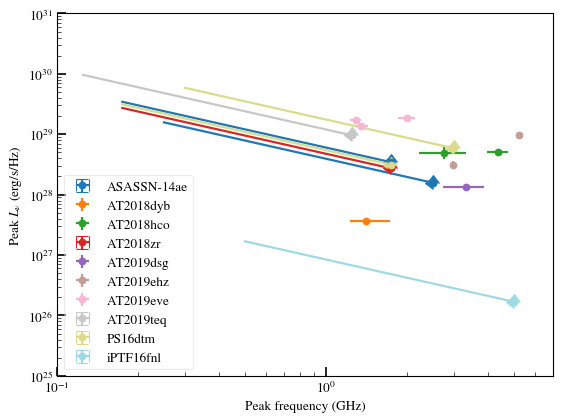

In [14]:
handles_list = []
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(0.1,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i])
plt.legend()
ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(0.1,7)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')

ASASSN-14ae lower limit on Lnu,p only
AT2018zr lower limit on Lnu,p only
AT2019teq lower limit on Lnu,p only
PS16dtm lower limit on Lnu,p only
iPTF16fnl lower limit on Lnu,p only


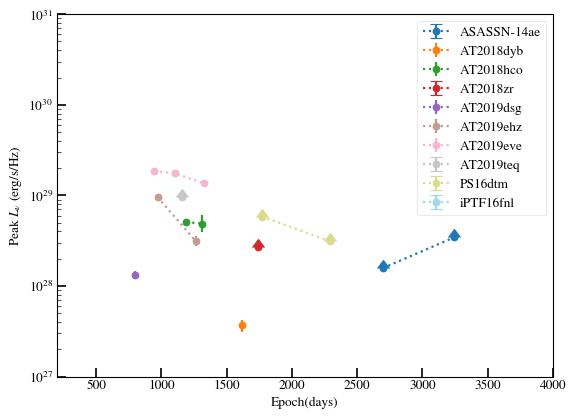

In [15]:
handles_list = []
colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])
    ax.errorbar(dict_SED_events[event_name]['epoch (d)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,fmt='o',lolims=lolims,ms=6,
                label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
ax.set_xlim(200,4000)
ax.set_ylim(1e27,1e31)
ax.set_xlabel('Epoch(days)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
# ax.set_xscale('log')
ax.set_yscale('log')  

## Power law circumnuclear density

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, 'Power-law density ISM models')

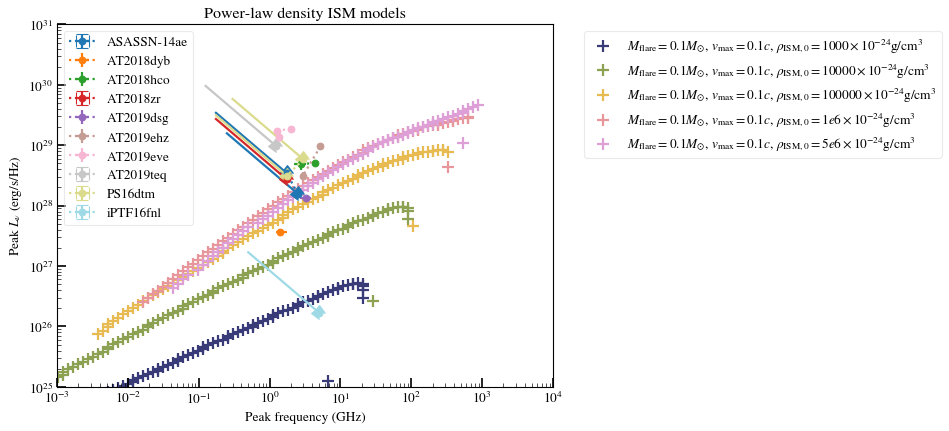

In [16]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(0.1,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
legend1=plt.legend()
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_powerlawism_list)))
for i,datadir in enumerate(datadir_powerlawism_list):

    flare2_dict = {}


    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_powerlawism_list[i],marker='+')
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-3,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('Power-law density ISM models')

iPTF16fnl: Mflare=0.1Msun/rho_ISM,0=1e4 m_H 

AT2018dyb is somewhere between  Mflare=0.1Msun/rho_ISM,0=1e4--1e5 m_H 

AT2019dsg, ASASSN-14ae, AT2019ehz, AT2018hco maybe work w/ Mflare=0.1Msun/rho_ISM,0=1e5--5e6 m_H

## Constant density ISM

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, 'Constant density ISM models')

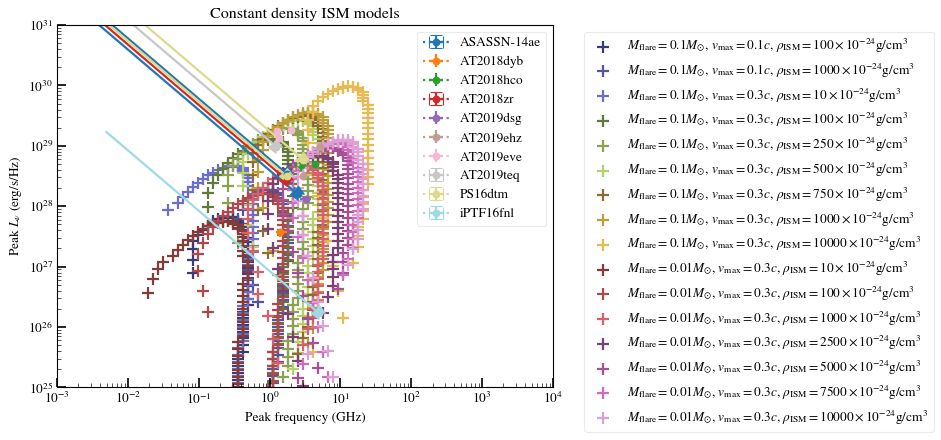

In [17]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    # print(dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'])
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(1e-3,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
legend1=plt.legend()
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))
for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}


    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_constism_list[i],marker='+')
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-3,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('Constant density ISM models')

For iPTF16fnl: idxs=[0,1,2,3,6,7,9,10,12,13,14,15]

for others: idxs=[3,4,5,6,7,8,11,12,13,14,15]

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, 'Constant density ISM models')

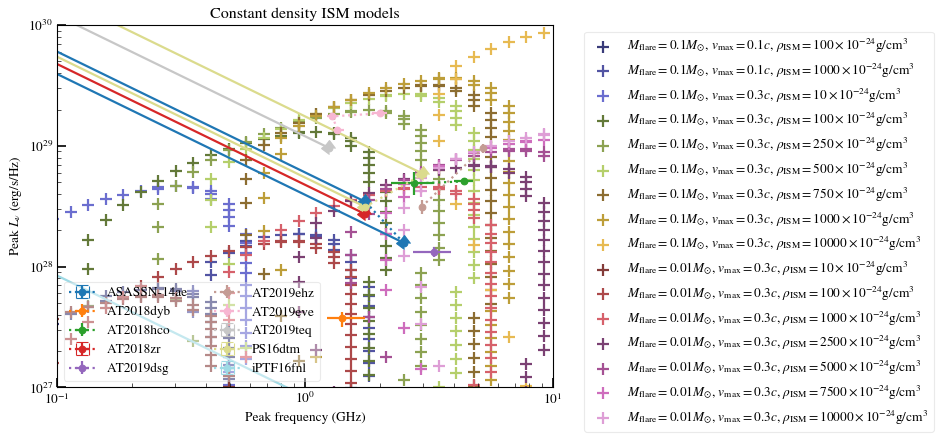

In [19]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    # print(dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'])
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(1e-3,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':')
plt.legend()
legend1=plt.legend(ncol=2)
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))
for i,datadir in enumerate(datadir_constism_list):

    flare2_dict = {}


    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_constism_list[i],marker='+')
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-1,1e1)
ax.set_ylim(1e27,1e30)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('Constant density ISM models')

## Two flares colliding

ASASSN-14ae lower limit on Lnu,p only
ASASSN-14ae upper limit on nu,p only
AT2018zr lower limit on Lnu,p only
AT2018zr upper limit on nu,p only
AT2019teq lower limit on Lnu,p only
AT2019teq upper limit on nu,p only
PS16dtm lower limit on Lnu,p only
PS16dtm upper limit on nu,p only
iPTF16fnl lower limit on Lnu,p only
iPTF16fnl upper limit on nu,p only


Text(0.5, 1.0, '2-flare models')

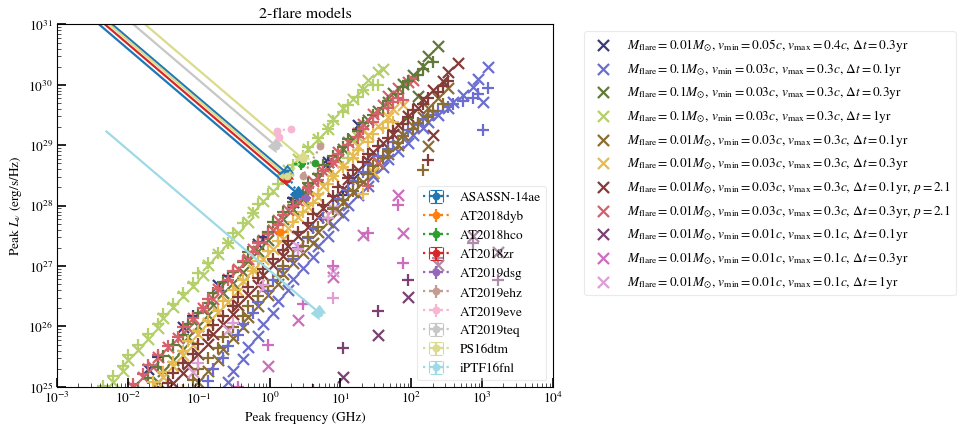

In [18]:

colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_SED_events.keys())))
fig,ax = plt.subplots(figsize=(8, 6))

for i,event_name in enumerate(dict_SED_events.keys()):
    if dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)'][0] == 0 and dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)'][0] == 0:
        lolims=True
        yerr=0
        print(event_name,'lower limit on Lnu,p only')
    else:
        lolims=False
        yerr=np.vstack([np.abs(dict_SED_events[event_name]['peak Lnu loerr (erg/s/Hz)']), dict_SED_events[event_name]['peak Lnu uperr (erg/s/Hz)']])

    if dict_SED_events[event_name]['peak freq uperr (GHz)'][0] == 0 and dict_SED_events[event_name]['peak freq loerr (GHz)'][0] == 0:
        xuplims=True
        xerr=0
        print(event_name,'upper limit on nu,p only')
        for freq,Lnu in zip(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)']):
            freq_range = np.linspace(1e-3,1)
            plt.plot(freq*freq_range, Lnu*(freq_range)**(-1),color=colors_array[i])
    else:
        xuplims=False
        xerr=np.vstack([np.abs(dict_SED_events[event_name]['peak freq loerr (GHz)']), dict_SED_events[event_name]['peak freq uperr (GHz)']])
    
    ax.errorbar(dict_SED_events[event_name]['peak freq (GHz)'],dict_SED_events[event_name]['peak Lnu (erg/s/Hz)'], yerr=yerr,lolims=lolims, xerr=xerr,xuplims=xuplims,
                fmt='o',ms=6, label=f'{event_name}',color=colors_array[i],linestyle=':',zorder=10)
plt.legend()
legend1=plt.legend()
ax.add_artist(legend1)

handles_list=[]
colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))
for i,datadir in enumerate(datadir_2flares_list):

    flare1_dict = {}
    flare2_dict = {}

    flare1_dict['peak_data'] = np.load(datadir+'/flare1/'+'peak_data.npz')
    flare2_dict['peak_data'] = np.load(datadir+'/flare2/'+'peak_data.npz')

    ax.scatter(flare1_dict['peak_data']['nu_pk']/1e9, flare1_dict['peak_data']['Lnu_pk'],color=colors_array[i],marker='+')
    l = ax.scatter(flare2_dict['peak_data']['nu_pk']/1e9, flare2_dict['peak_data']['Lnu_pk'],color=colors_array[i],label=names_2flares_list[i],marker='x',zorder=0)
    handles_list.append(l)
plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xscale('log')
ax.set_yscale('log')    
ax.set_xlim(1e-3,1e4)
ax.set_ylim(1e25,1e31)
ax.set_xlabel('Peak frequency (GHz)')
ax.set_ylabel(r'Peak $L_{\nu}$ (erg/s/Hz)')
plt.title('2-flare models')

For iPTF16fnl: all but Mflare=0.01Msun/vmax=0.1c/deltat=0.1yr fit.
for AT2018dyb: Mflare=0.01Msun/vmax=0.3c/deltat=0.3yr fits. also p=2.1/deltat=0.3yr

for others: keep Mflare=0.1Msun/vmax=0.3c/deltat=0.3yr and deltat=1yr. also p=2.1 ones

# Light curve comparisons

## Power law circumnuclear density

In [19]:
def plot_powerlawdensity_LCs(idx_list,dt_shift,eventname,freqtolabel=5,freq_delta=1):
    #for iPTF16fnl
    # idxs_iPTF16fnl_list = np.array([2,3,4,8,9])

    fig,ax = plt.subplots(figsize=(8, 6))
    colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
    for event,color in zip(dict_events.keys(), colors_array):
        if event != eventname: #good ones: AT2019eve w/dt_shift=6e2; AT2018hco w/dt_shift=5e2, AT2019teq w/dt_shift = 2e2, AT2018zr w/dt_shift=1.5e3, iPTF16fnl, AT2019dsg w/dt_shift=7e2, AT2019ehz w/dt_shift=5e2, AT2018hco w/dt_shift=5e2
            continue
        marker_array = ['o']#,'s','D', '*','^','<','>','p','h','8']
        marker_num =0
        for freq in np.unique(dict_events[event]['freq (GHz)']):
            
            if np.abs(freq-6) > freq_delta:
                continue
            if np.abs(freq-freqtolabel) == 0:
                label= f'{event} 6 GHz'
            else:
                label = None
            freq_array = np.array([],dtype=int)
            uplims_array = np.array([],dtype=bool)
            for i in range(len(dict_events[event]['freq (GHz)'])):
                if dict_events[event]['freq (GHz)'][i] == freq:
                    # print(i)
                    freq_array = np.append(freq_array,i)
                    if dict_events[event]['error (mJy)'][i] == 0:
                        uplims_array = np.append(uplims_array,True)
                    else:
                        uplims_array = np.append(uplims_array,False)
            if len(uplims_array[uplims_array]) == len(freq_array):
                continue            
            # print(dict_events[event]['freq (GHz)'][freq_array],dict_events[event]['times (d)'][freq_array])
            ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                        yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                        ms=6, color=color, label=label)
            # marker_num+=1
    legend1=ax.legend()
    ax.add_artist(legend1)
    handles_list=[]
    colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_powerlawism_list)))

    # dt_shift = 5e2 # days

    for i in idx_list:
        datadir = datadir_powerlawism_list[i]
        flare2_dict = {}


        flare2_dict['Lnu_6GHz'] = np.load(datadir+'/flare2/'+'Lnu_6.00GHz_sparse_Te_1.0E+04.npz')

        # l, = ax.plot(flare2_dict['Lnu_6GHz']['times_yr']*365.25,(flare2_dict['Lnu_6GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_powerlawism_list[i])
        l, = ax.plot(flare2_dict['Lnu_6GHz']['times_yr']*365.25 + dt_shift,(flare2_dict['Lnu_6GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_powerlawism_list[i],ls='-')
        handles_list.append(l)

        

    plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(10,1e4)
    ax.set_ylim(1e25,1e31)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
    plt.title('Power law density ISM models')

    return

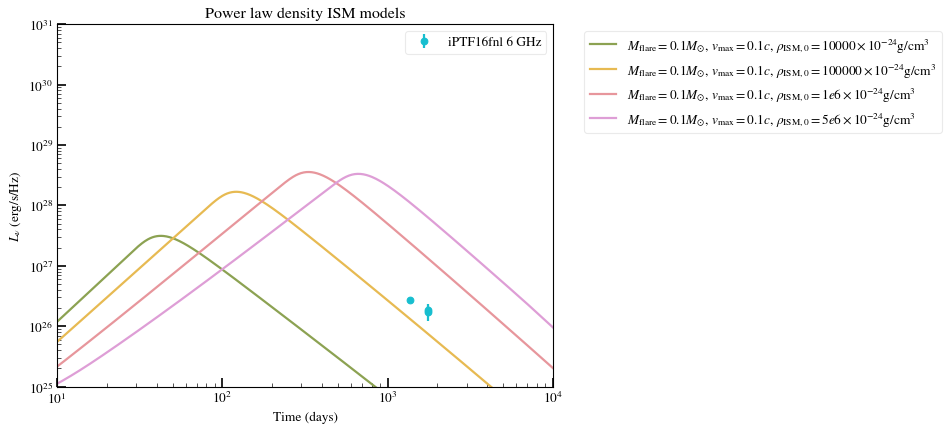

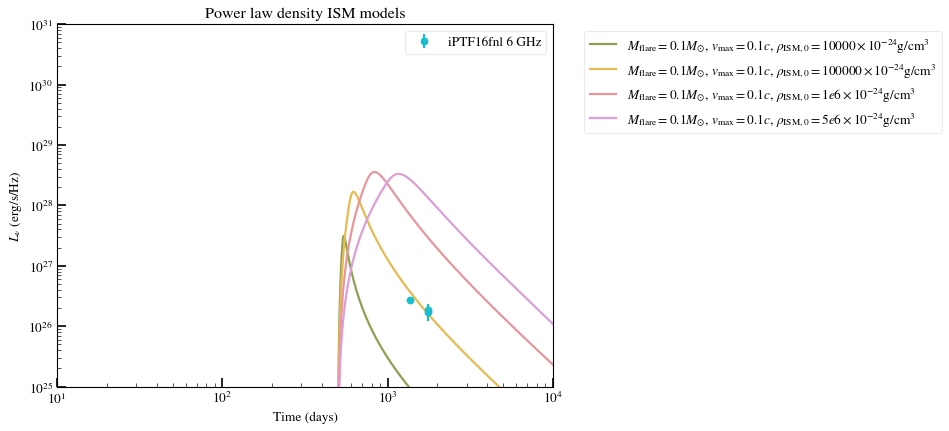

In [20]:
idxs_iPTF16fnl_list = np.array([1,2,3,4])

plot_powerlawdensity_LCs(idxs_iPTF16fnl_list,dt_shift=0,eventname='iPTF16fnl')
plot_powerlawdensity_LCs(idxs_iPTF16fnl_list,dt_shift=5e2,eventname='iPTF16fnl')

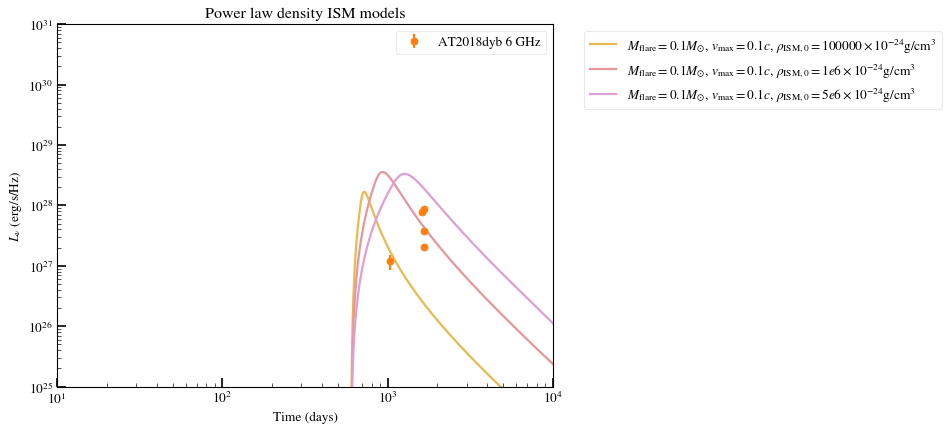

In [50]:
idxs_AT2018dyb_list = np.array([2,3,4])

# plot_powerlawdensity_LCs(idxs_AT2018dyb_list,dt_shift=0,eventname='AT2018dyb',freq_delta=5)
plot_powerlawdensity_LCs(idxs_AT2018dyb_list,dt_shift=6e2,eventname='AT2018dyb',freq_delta=5,freqtolabel=5.5)

In [47]:
len(names_powerlawism_list)

5

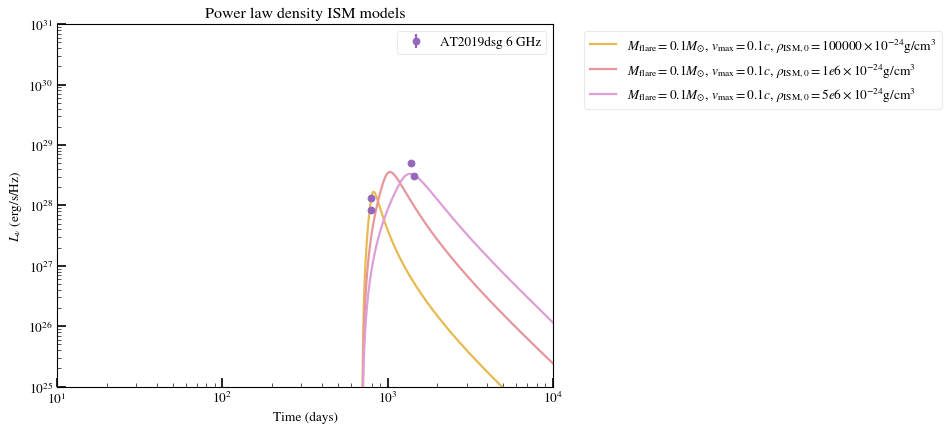

In [22]:
idxs_AT2019dsg_list = np.array([2,3,4])

plot_powerlawdensity_LCs(idxs_AT2019dsg_list,dt_shift=7e2,eventname='AT2019dsg',freq_delta=1)

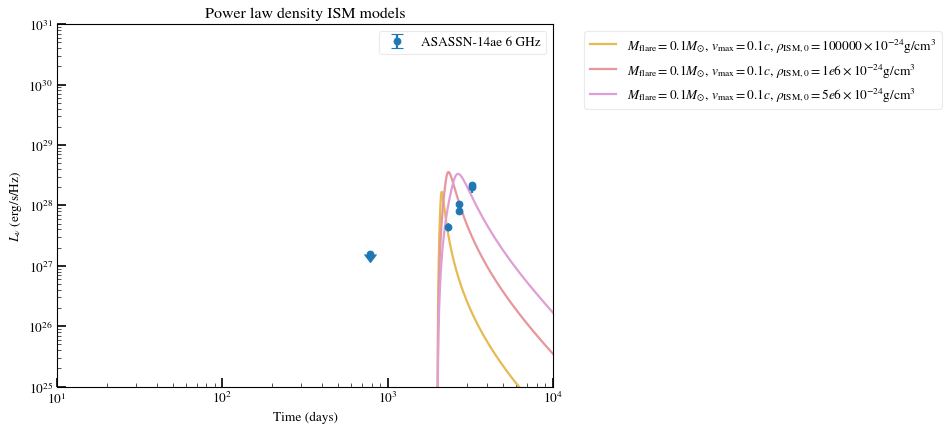

In [23]:
idxs_ASASSN14ae_list = np.array([2,3,4])

plot_powerlawdensity_LCs(idxs_ASASSN14ae_list,dt_shift=2e3,eventname='ASASSN-14ae',freq_delta=1)

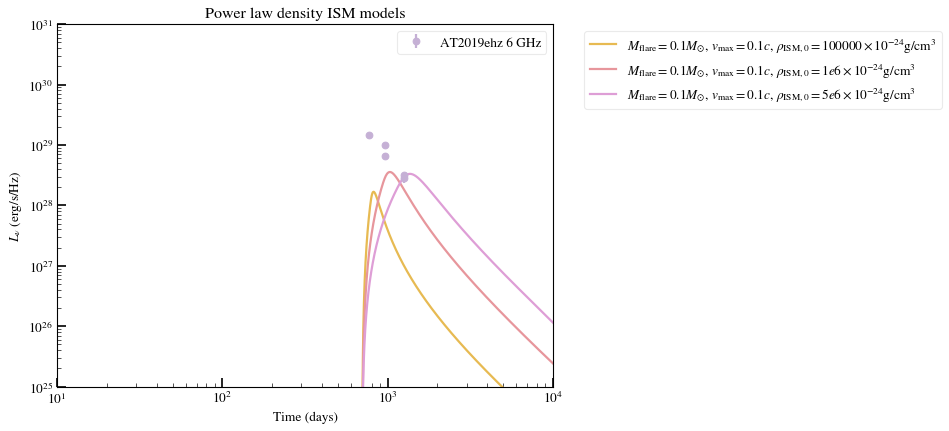

In [24]:
idxs_AT2019ehz_list = np.array([2,3,4])

plot_powerlawdensity_LCs(idxs_AT2019ehz_list,dt_shift=7e2,eventname='AT2019ehz',freq_delta=1)

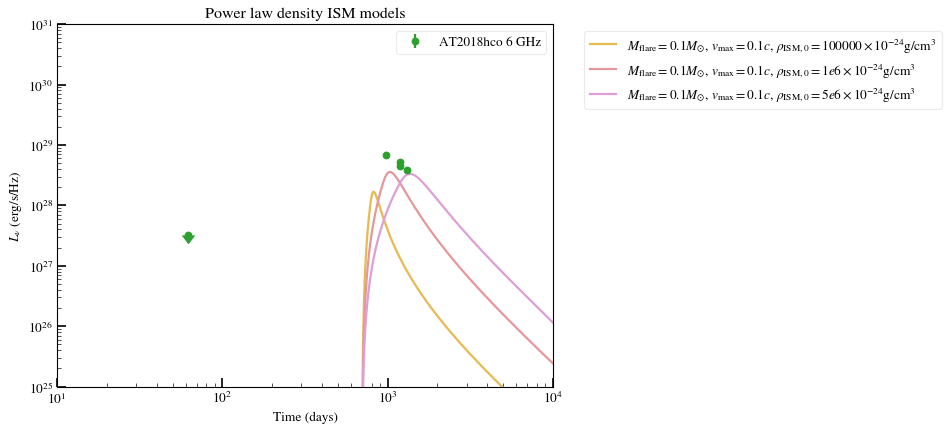

In [25]:
idxs_AT2018hco_list = np.array([2,3,4])

plot_powerlawdensity_LCs(idxs_AT2018hco_list,dt_shift=7e2,eventname='AT2018hco',freq_delta=1)

setting dictionary of the good events + associated models + dt_shifts

In [52]:
dict_powerlawism_toSED = {}
dict_powerlawism_toSED['iPTF16fnl']={names_powerlawism_list[2]:5e2} #or maybe something intermediate, like n_ISM,0=5e5
dict_powerlawism_toSED['AT2018dyb']={names_powerlawism_list[3]:7e2}

## Constant density ISM

In [27]:
def plot_constdensity_LCs(idx_list,dt_shift,eventname,freqtolabel=5,freq_delta=1):
    #for iPTF16fnl
    # idxs_iPTF16fnl_list = np.array([2,3,4,8,9])

    fig,ax = plt.subplots(figsize=(8, 6))
    colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
    for event,color in zip(dict_events.keys(), colors_array):
        if event != eventname: #good ones: AT2019eve w/dt_shift=6e2; AT2018hco w/dt_shift=5e2, AT2019teq w/dt_shift = 2e2, AT2018zr w/dt_shift=1.5e3, iPTF16fnl, AT2019dsg w/dt_shift=7e2, AT2019ehz w/dt_shift=5e2, AT2018hco w/dt_shift=5e2
            continue
        marker_array = ['o']#,'s','D', '*','^','<','>','p','h','8']
        marker_num =0
        for freq in np.unique(dict_events[event]['freq (GHz)']):
            
            if np.abs(freq-6) > freq_delta:
                continue
            if np.abs(freq-freqtolabel) == 0:
                label= f'{event} 6 GHz'
            else:
                label = None
            freq_array = np.array([],dtype=int)
            uplims_array = np.array([],dtype=bool)
            for i in range(len(dict_events[event]['freq (GHz)'])):
                if dict_events[event]['freq (GHz)'][i] == freq:
                    # print(i)
                    freq_array = np.append(freq_array,i)
                    if dict_events[event]['error (mJy)'][i] == 0:
                        uplims_array = np.append(uplims_array,True)
                    else:
                        uplims_array = np.append(uplims_array,False)
            if len(uplims_array[uplims_array]) == len(freq_array):
                continue            
            # print(dict_events[event]['freq (GHz)'][freq_array],dict_events[event]['times (d)'][freq_array])
            ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                        yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                        ms=6, color=color, label=label)
            # marker_num+=1
    legend1=ax.legend()
    ax.add_artist(legend1)
    handles_list=[]
    colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_constism_list)))

    # dt_shift = 5e2 # days

    for i in idx_list:
        datadir = datadir_constism_list[i]
        flare2_dict = {}


        flare2_dict['Lnu_6GHz'] = np.load(datadir+'/flare2/'+'Lnu_6.00GHz_sparse_Te_1.0E+04.npz')

        # l, = ax.plot(flare2_dict['Lnu_6GHz']['times_yr']*365.25,(flare2_dict['Lnu_6GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i])
        l, = ax.plot(flare2_dict['Lnu_6GHz']['times_yr']*365.25 + dt_shift,(flare2_dict['Lnu_6GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_constism_list[i],ls='-')
        handles_list.append(l)

        

    plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(10,1e4)
    ax.set_ylim(1e25,1e31)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
    plt.title('Constant density ISM models')

    return

In [28]:
names_constism_list

['$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.1c$, $\\rho_{\\rm ISM} = 100 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.1c$, $\\rho_{\\rm ISM} = 1000 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 10 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 100 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 250 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 500 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 750 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 1000 \\times 10^{-24} \\mathrm{g/cm^3}$',
 '$M_{\\rm flare} = 0.1M_{\\odot}$, $v_

For iPTF16fnl: idxs=[0,1,2,3,6,7,9,10,12,13,14,15]

for others: idxs=[3,4,5,6,7,8,11,12,13,14,15]

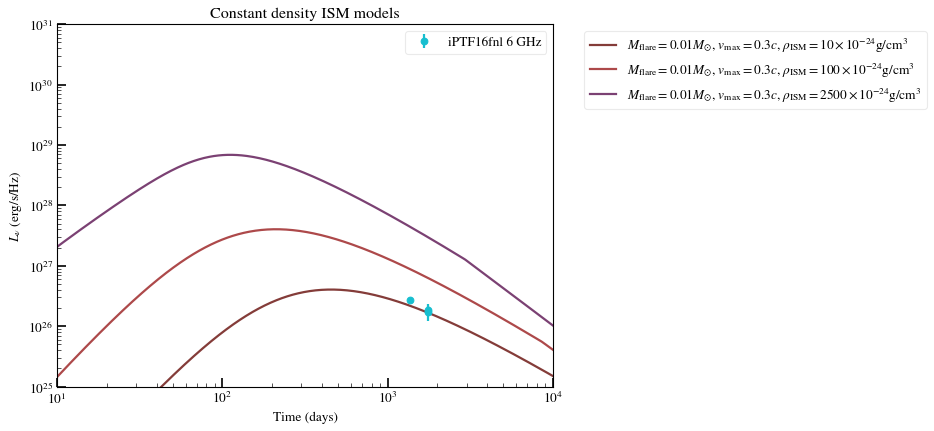

In [29]:
#for iPTF16fnl
idxs_iPTF16fnl_list = np.array([9,10,12])

plot_constdensity_LCs(idxs_iPTF16fnl_list,dt_shift=0,eventname='iPTF16fnl')

# plot_constdensity_LCs(idxs_iPTF16fnl_list,dt_shift=250,eventname='iPTF16fnl')

# # plot_constdensity_LCs(idxs_iPTF16fnl_list,dt_shift=5e2,eventname='iPTF16fnl')

# plot_constdensity_LCs(idxs_iPTF16fnl_list,dt_shift=1e3,eventname='iPTF16fnl')

# plot_constdensity_LCs(idxs_iPTF16fnl_list,dt_shift=1.25e3,eventname='iPTF16fnl')




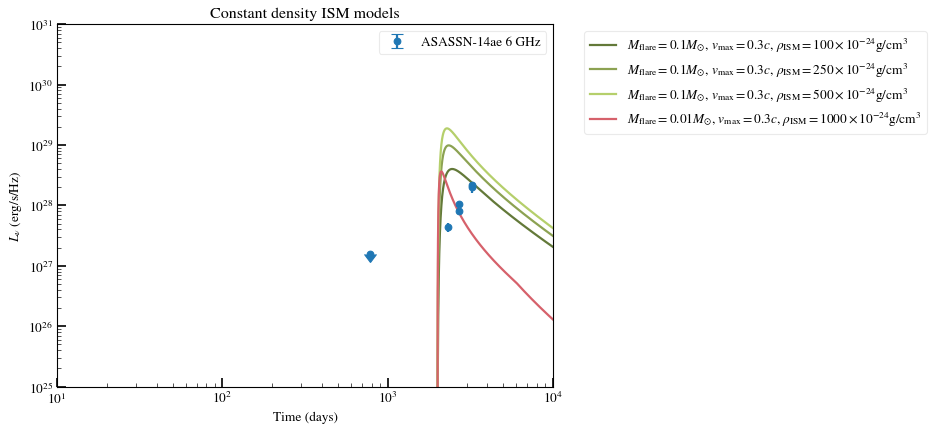

In [30]:

idxs_others_list = np.array([3,4,5,11])
plot_constdensity_LCs(idxs_others_list,dt_shift=2e3,eventname='ASASSN-14ae')


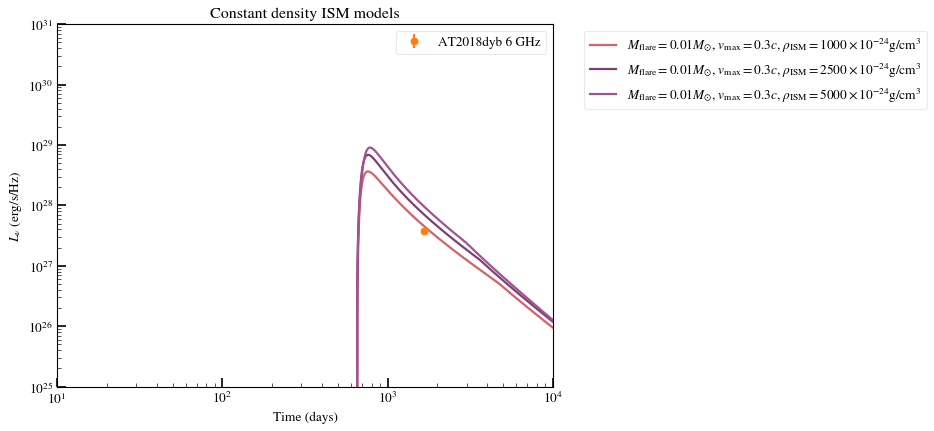

In [31]:
idxs_others_list = np.array([11,12,13])
plot_constdensity_LCs(idxs_others_list,dt_shift=6.5e2,eventname='AT2018dyb',freqtolabel=5.5,freq_delta=1)


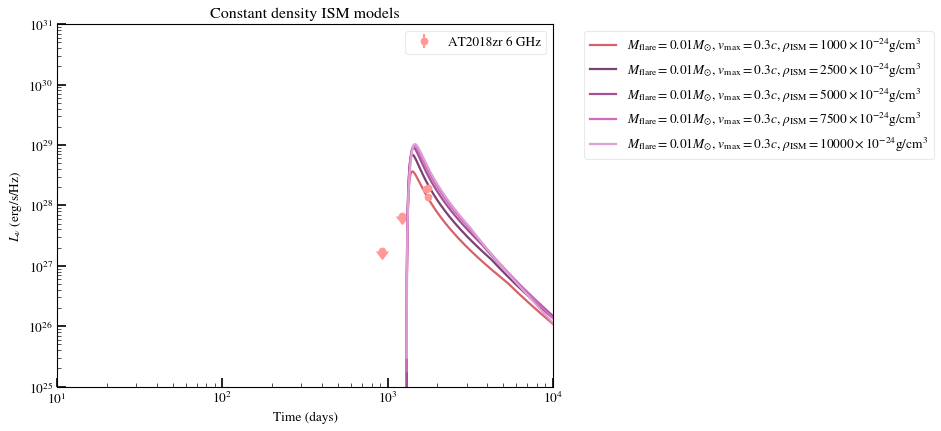

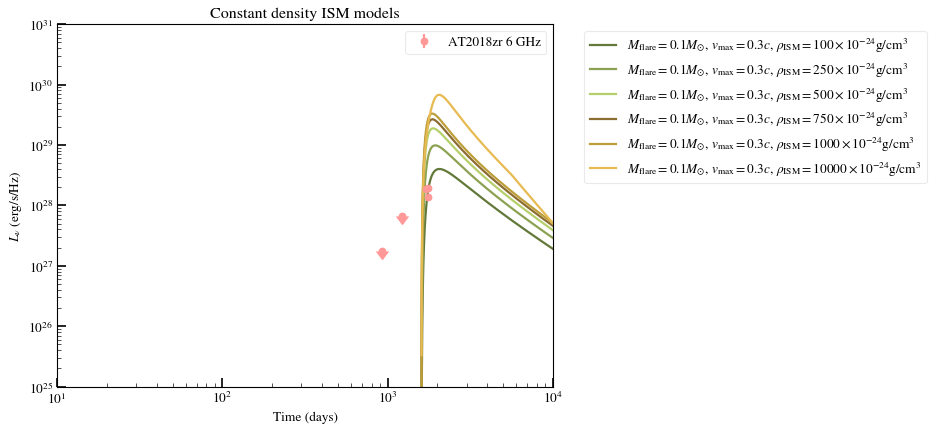

In [32]:

idxs_others_list = np.array([11,12,13,14,15])
plot_constdensity_LCs(idxs_others_list,dt_shift=1.3e3,eventname='AT2018zr')

idxs_others_list = np.array([3,4,5,6,7,8])
plot_constdensity_LCs(idxs_others_list,dt_shift=1.6e3,eventname='AT2018zr')

# plot_constdensity_LCs(idxs_others_list,dt_shift=7.e2,eventname='AT2019dsg',freq_delta=1) #this one is kind of weird. but the last two epochs are probably higher according to Cendes 2024 Figure 1

# plot_constdensity_LCs(idxs_others_list,dt_shift=5e2,eventname='AT2019ehz')

# plot_constdensity_LCs(idxs_others_list,dt_shift=4e2,eventname='AT2019eve')

# plot_constdensity_LCs(idxs_others_list,dt_shift=4e2,eventname='AT2019teq')

# plot_constdensity_LCs(idxs_others_list,dt_shift=1.25e3,eventname='PS16dtm')

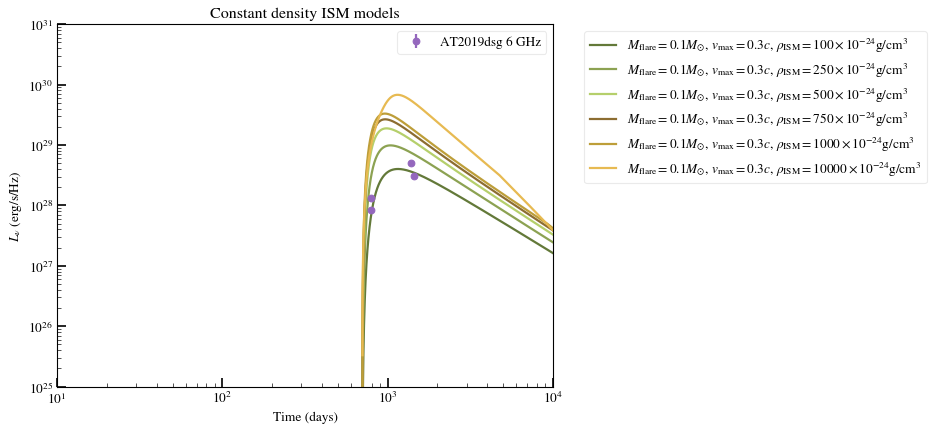

In [33]:
idxs_others_list = np.array([3,4,5,6,7,8])
plot_constdensity_LCs(idxs_others_list,dt_shift=7e2,eventname='AT2019dsg',freq_delta=1) #this one is kind of weird. but the last two epochs are probably higher according to Cendes 2024 Figure 1

# idxs_others_list = np.array([11,12,13,14,15])
# plot_constdensity_LCs(idxs_others_list,dt_shift=4e2,eventname='AT2019dsg',freq_delta=1) #this one is kind of weird. but the last two epochs are probably higher according to Cendes 2024 Figure 1


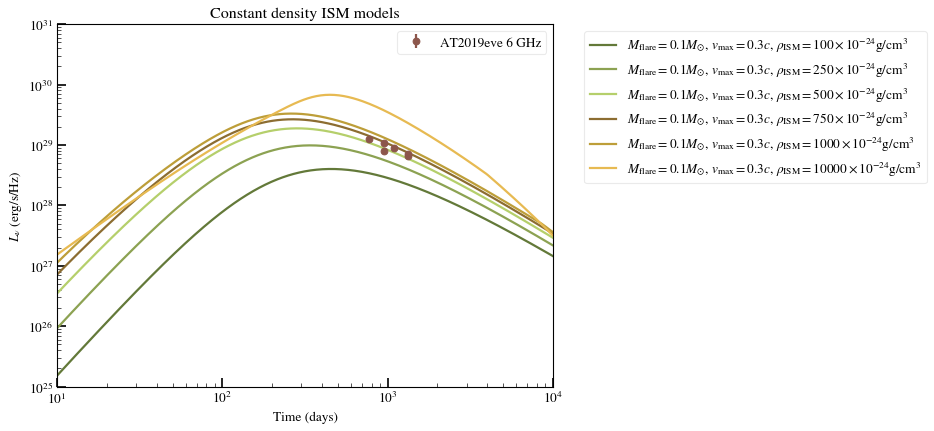

In [34]:
# idxs_others_list = np.array([3,4,5,6,7,9,10,11,12,13])
idxs_others_list = np.array([3,4,5,6,7,8])
plot_constdensity_LCs(idxs_others_list,dt_shift=0,eventname='AT2019eve')




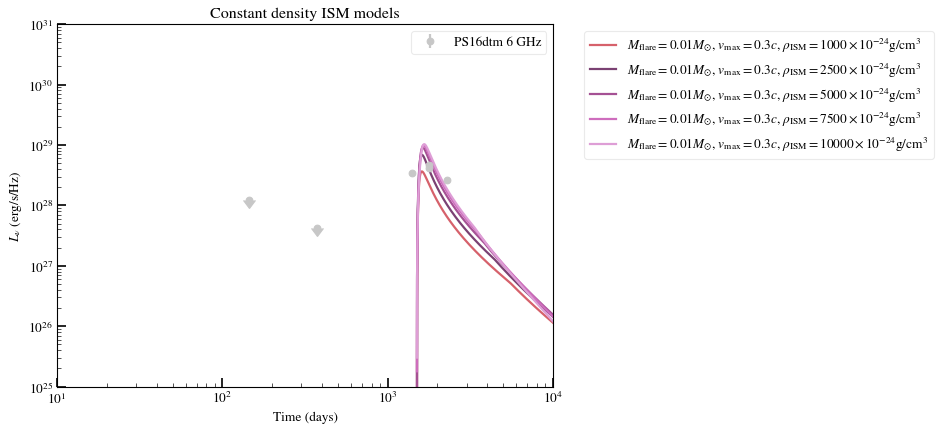

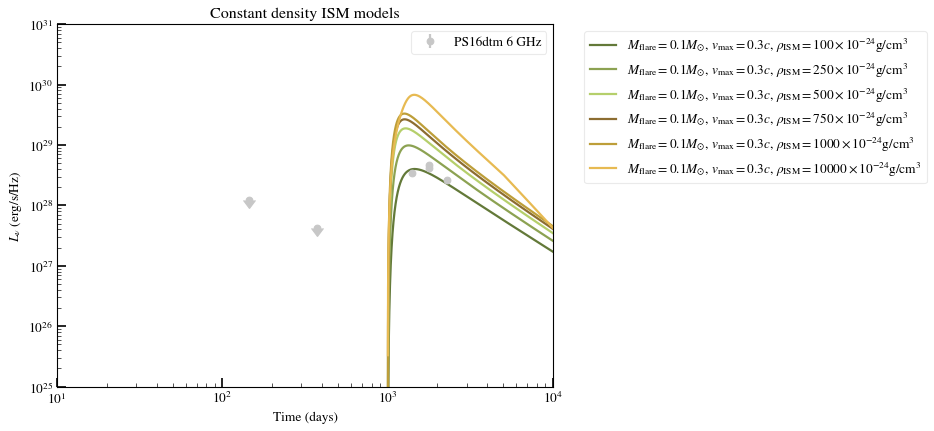

In [35]:
idxs_others_list = np.array([11,12,13,14,15])

plot_constdensity_LCs(idxs_others_list,dt_shift=1.5e3,eventname='PS16dtm')

idxs_others_list = np.array([3,4,5,6,7,8])

plot_constdensity_LCs(idxs_others_list,dt_shift=1e3,eventname='PS16dtm')

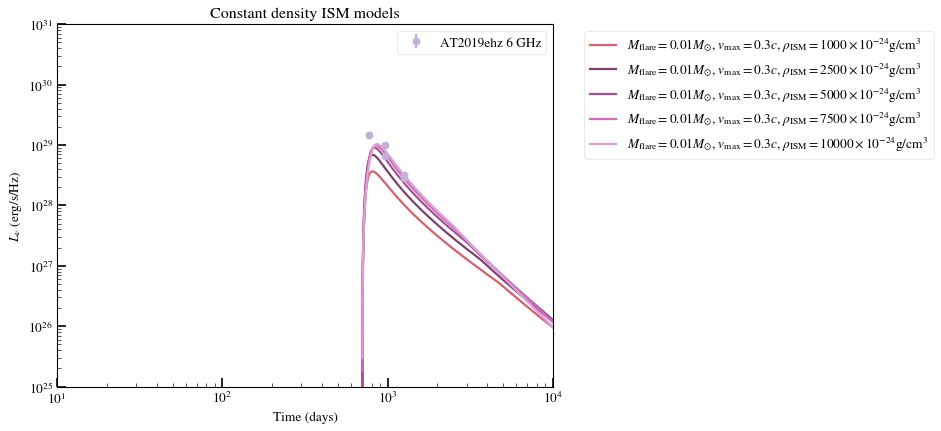

In [36]:
idxs_others_list = np.array([11,12,13,14,15])
plot_constdensity_LCs(idxs_others_list,dt_shift=7e2,eventname='AT2019ehz')
# idxs_others_list = np.array([3,4,5,6,7,8])
# plot_constdensity_LCs(idxs_others_list,dt_shift=1e2,eventname='AT2019ehz')

setting dictionary of the good events + associated models + dt_shifts

TODO

In [37]:
dict_constism_toSED = {}
dict_constism_toSED['iPTF16fnl']={names_constism_list[9]:0 }
dict_constism_toSED['ASASSN-14ae']={names_constism_list[7]:1.9e3}
dict_constism_toSED['AT2018dyb']={names_constism_list[6]:6.5e2}
dict_constism_toSED['AT2018zr']={names_constism_list[15]:1.2e3}
dict_constism_toSED['AT2019dsg']={names_constism_list[8]:4e2}
dict_constism_toSED['AT2019eve']={names_constism_list[7]:1e2}
dict_constism_toSED['PS16dtm']={names_constism_list[15]:1.25e3} #this is close but too dim, might be something in between 1000 and 10000

## Two flares colliding

In [38]:
def plot_2flare_LCs(idx_list,dt_shift,eventname,freqtolabel=6,freq_delta=1):
    #for iPTF16fnl
    # idxs_iPTF16fnl_list = np.array([2,3,4,8,9])

    fig,ax = plt.subplots(figsize=(8, 6))
    colors_array = plt.cm.tab20(np.linspace(0, 1, len(dict_events.keys())))
    for event,color in zip(dict_events.keys(), colors_array):
        if event != eventname: #good ones: AT2019eve w/dt_shift=6e2; AT2018hco w/dt_shift=5e2, AT2019teq w/dt_shift = 2e2, AT2018zr w/dt_shift=1.5e3, iPTF16fnl, AT2019dsg w/dt_shift=7e2, AT2019ehz w/dt_shift=5e2, AT2018hco w/dt_shift=5e2
            continue
        marker_array = ['o']#,'s','D', '*','^','<','>','p','h','8']
        marker_num =0
        for freq in np.unique(dict_events[event]['freq (GHz)']):
            if np.abs(freq-6) > freq_delta:
                continue
            print(freq)
            if np.abs(freq-freqtolabel) ==0:
                label= f'{event} 6 GHz'
            else:
                label = None
            freq_array = np.array([],dtype=int)
            uplims_array = np.array([],dtype=bool)
            for i in range(len(dict_events[event]['freq (GHz)'])):
                if dict_events[event]['freq (GHz)'][i] == freq:
                    # print(i)
                    freq_array = np.append(freq_array,i)
                    if dict_events[event]['error (mJy)'][i] == 0:
                        uplims_array = np.append(uplims_array,True)
                    else:
                        uplims_array = np.append(uplims_array,False)
            if len(uplims_array[uplims_array]) == len(freq_array):
                continue            
            ax.errorbar(dict_events[event]['times (d)'][freq_array], dict_events[event]['Lnu (erg/s/Hz)'][freq_array], 
                        yerr=dict_events[event]['error (erg/s/Hz)'][freq_array], fmt=marker_array[marker_num], uplims=uplims_array,  
                        ms=6, color=color, label=label)
            # marker_num+=1
    legend1=ax.legend()
    ax.add_artist(legend1)
    
    handles_list=[]
    colors_array = plt.cm.tab20b(np.linspace(0, 1, len(datadir_2flares_list)))

    for i in idx_list:
        datadir = datadir_2flares_list[i]

        flare1_dict = {}
        flare2_dict = {}

        flare1_dict['Lnu_6GHz'] = np.load(datadir+'/flare1/'+'Lnu_6.00GHz_sparse_Te_1.0E+04.npz')
        flare2_dict['Lnu_6GHz'] = np.load(datadir+'/flare2/'+'Lnu_6.00GHz_sparse_Te_1.0E+04.npz')

        l, = ax.plot(flare1_dict['Lnu_6GHz']['times_yr']*365.25 + dt_shift,(flare1_dict['Lnu_6GHz']['Lnu_abs_atfreq']+flare2_dict['Lnu_6GHz']['Lnu_abs_atfreq']),color=colors_array[i],label=names_2flares_list[i])
        handles_list.append(l)
    plt.legend(handles=handles_list,bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(1e2,4000)
    ax.set_ylim(1e26,1e30)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(r'$L_{\nu}$ (erg/s/Hz)')
    plt.title('2 Flare models')

    return

5.0
6.0
7.0


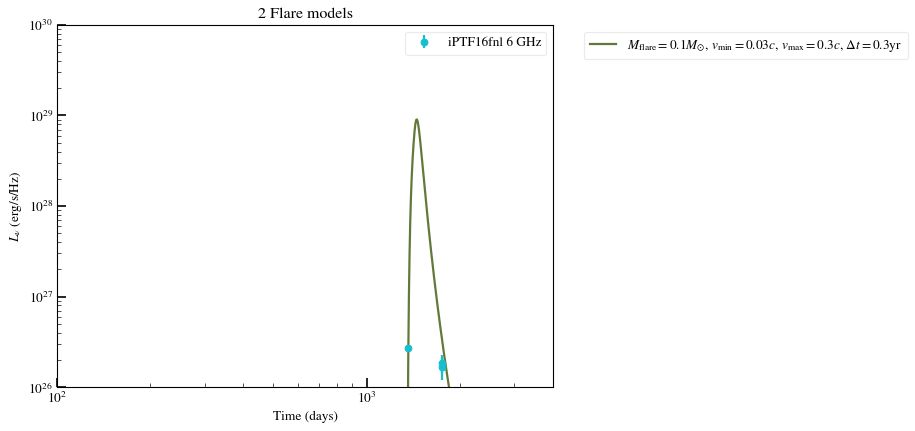

In [39]:
idxs_iPTF16fnl_list = np.array([2]) #5,6,7
plot_2flare_LCs(idxs_iPTF16fnl_list,dt_shift=1.3e3,eventname='iPTF16fnl',freqtolabel=6)

1.36
2.1
5.5
9.0


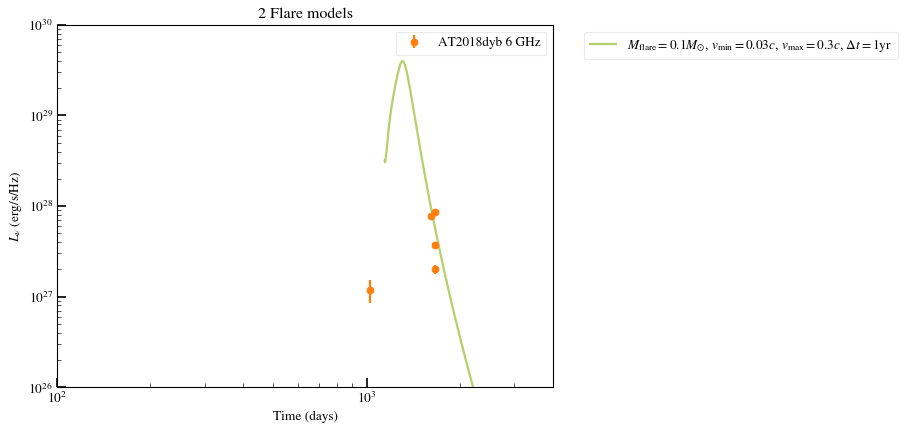

In [40]:
idxs_AT2018dyb_list = np.array([3])
plot_2flare_LCs(idxs_AT2018dyb_list,dt_shift=1.1e3,eventname='AT2018dyb',freqtolabel=5.5,freq_delta=5)

In [41]:
dict_SED_events.keys()

dict_keys(['ASASSN-14ae', 'AT2018dyb', 'AT2018hco', 'AT2018zr', 'AT2019dsg', 'AT2019ehz', 'AT2019eve', 'AT2019teq', 'PS16dtm', 'iPTF16fnl'])

5.0
6.0
7.0
5.0
5.5
6.0
7.0
5.0
6.0
7.0


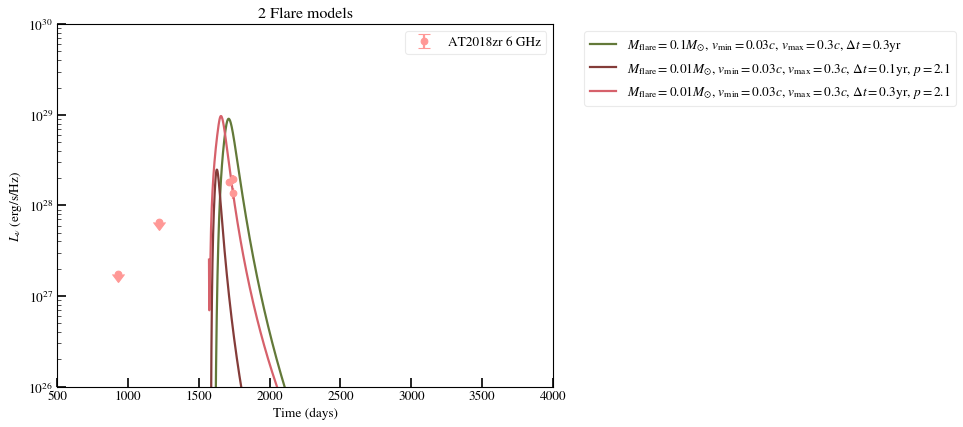

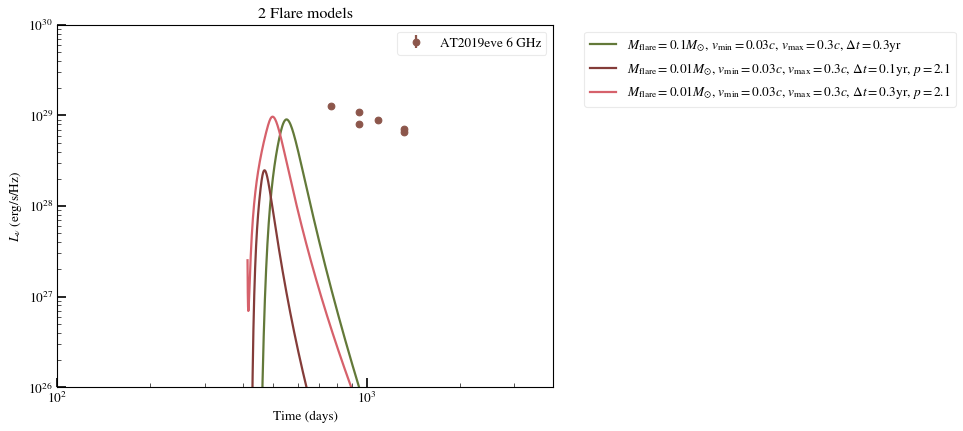

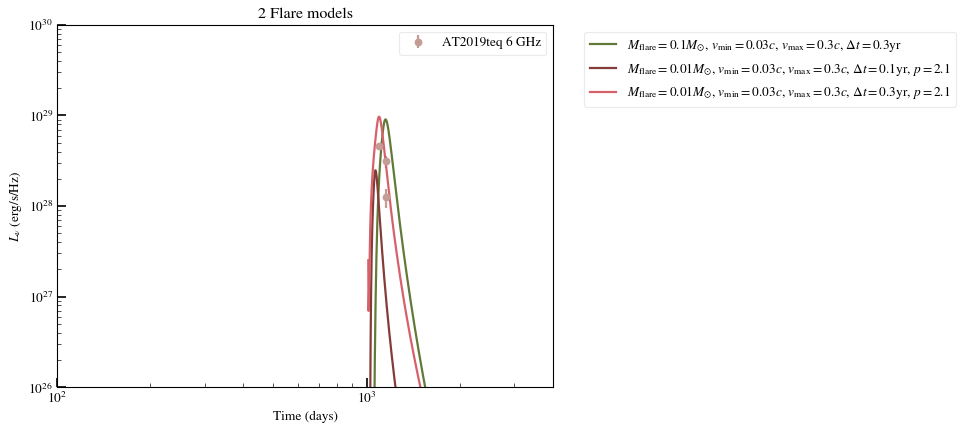

In [42]:
idxs_others_list = np.array([2,6,7])
# plot_2flare_LCs(idxs_others_list,dt_shift=1e3,eventname='ASASSN-14ae')
# plot_2flare_LCs(idxs_others_list,dt_shift=1e3,eventname='AT2018hco')

plot_2flare_LCs(idxs_others_list,dt_shift=1.56e3,eventname='AT2018zr',freq_delta=1)
plt.xlim(500,)
plt.xscale('linear')

# plot_2flare_LCs(idxs_others_list,dt_shift=9e2,eventname='AT2019dsg',freqtolabel=7)

# plot_2flare_LCs(idxs_others_list,dt_shift=1e3,eventname='AT2019ehz')

plot_2flare_LCs(idxs_others_list,dt_shift=4e2,eventname='AT2019eve')

plot_2flare_LCs(idxs_others_list,dt_shift=1e3,eventname='AT2019teq')

# plot_2flare_LCs(idxs_others_list,dt_shift=1.5e3,eventname='PS16dtm')



setting arrays of the good events + associated models + dt_shifts

In [43]:
dict_2flares_toSED = {}
dict_2flares_toSED['iPTF16fnl']={names_2flares_list[2]:1.3e3}
dict_2flares_toSED['AT2018dyb']={names_2flares_list[3]:1.1e3}
dict_2flares_toSED['AT2018zr']={names_2flares_list[2]:1.5e3,names_2flares_list[7]:1.56e3}
dict_2flares_toSED['AT2019teq']={names_2flares_list[2]:9.25e2,names_2flares_list[7]:1e3}

# SED Comparisons given good events + dt_shifts noted above

## Power law circumnuclear density

In [35]:
dict_powerlawism_toSED

{'iPTF16fnl': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.1c$, $\\rho_{\\rm ISM,0} = 5 \\times 10^{-18} \\mathrm{g/cm^3}$': 0},
 'AT2018dyb': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.1c$, $\\rho_{\\rm ISM,0} = 10^{-18} \\mathrm{g/cm^3}$': 1300.0}}

In [44]:
def plot_rhoISM_SED(model_name,modeldict_name,event_name,epoch_delta,range_to_incl=500):

    
    fig,ax = plt.subplots(figsize=(8, 6))

    # linestyles = ['-','--',':','-.','-']
    # for i, model_name in enumerate(sorted(os.listdir(model_dir))):
        # if i >=2:
        #     continue
    
    approx_time = np.average(dict_events[event_name]['times (d)'])
    print(model_name,event_name,approx_time)

    SEDs_dict = np.load(modeldict_name[model_name]+'/flare2/SED_data.npz',allow_pickle=True)['SED_vs_epoch'].item()
    colors = plt.cm.tab20b(np.linspace(0, 1, len(SEDs_dict.keys())))
    for j, key in enumerate(SEDs_dict.keys()):

        if key=='nu_ph_vals_GHz':
            continue
        epoch = float(key.split('_')[-1])+epoch_delta
        
        if np.abs(epoch-approx_time) > range_to_incl:
            continue
        # if i==0:
        label_to_use='{:0.0f} d'.format(epoch)
        # else:
        #     label_to_use = None
        ax.plot(SEDs_dict['nu_ph_vals_GHz'],SEDs_dict[key],label=label_to_use,linestyle='-',color=colors[j])

    colors2 = plt.cm.tab20_r(np.linspace(0, 1, len(np.unique(dict_events[event_name]['times (d)']))))
    print(len(np.unique(dict_events[event_name]['times (d)'])))
    for j,epoch in enumerate(np.unique(dict_events[event_name]['times (d)'])):

        epoch_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event_name]['times (d)'])):
            if dict_events[event_name]['times (d)'][i] == epoch:
                # print(i)
                epoch_array = np.append(epoch_array,i)
                if dict_events[event_name]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        if len(epoch_array) == 1:
            continue
        ax.errorbar(dict_events[event_name]['freq (GHz)'][epoch_array], dict_events[event_name]['Lnu (erg/s/Hz)'][epoch_array], 
                    yerr=dict_events[event_name]['error (erg/s/Hz)'][epoch_array], fmt='o',  uplims=uplims_array,
                    ms=6, label=event_name+f' {epoch} d',color=colors2[j],linestyle=':')
                    # unique=False
    ax.text(0.95, 0.95, f'shifted by {epoch_delta:0.0f} d', transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='right')
    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(1e-2,1e3)
    ax.set_ylim(1e24,1e31)
    ax.set_xlabel(r'$\nu$ (GHz)')
    ax.set_ylabel(r'$L_\nu$ (erg/s/Hz)')
    plt.title(f'{model_name}')
    plt.legend(loc='upper left')
    return

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 100000 \times 10^{-24} \mathrm{g/cm^3}$ iPTF16fnl 1687.5
2


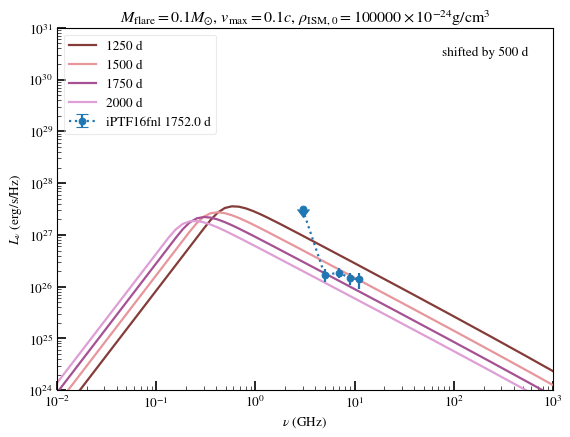

In [47]:
keys_list = list(dict_powerlawism_toSED['iPTF16fnl'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_powerlawism,event_name = 'iPTF16fnl',epoch_delta=dict_powerlawism_toSED['iPTF16fnl'][keys_list[0]])

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.1c$, $\rho_{\rm ISM,0} = 1e6 \times 10^{-24} \mathrm{g/cm^3}$ AT2018dyb 1522.8
3


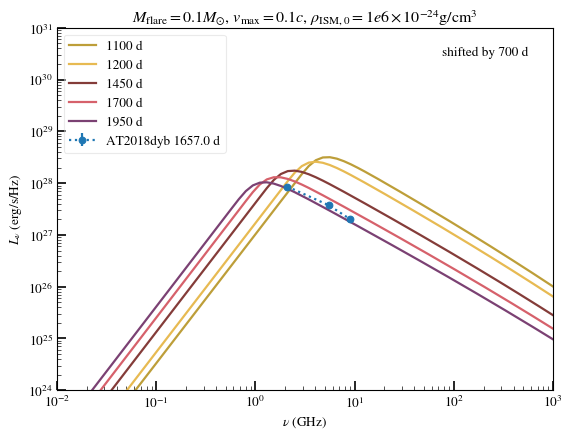

In [53]:
keys_list = list(dict_powerlawism_toSED['AT2018dyb'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_powerlawism,event_name = 'AT2018dyb',epoch_delta=dict_powerlawism_toSED['AT2018dyb'][keys_list[0]])

## Constant density ISM

$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 10 \times 10^{-24} \mathrm{g/cm^3}$ iPTF16fnl 1687.5
2


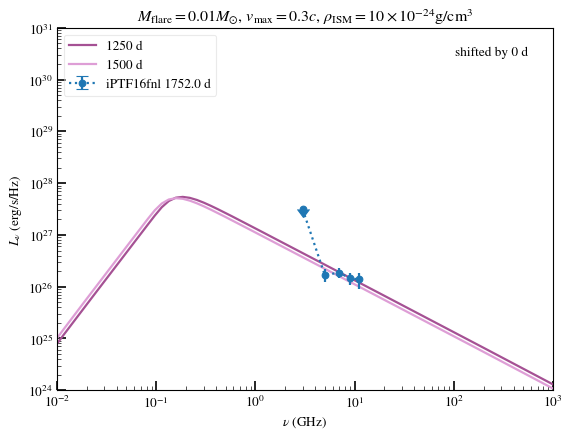

In [54]:
keys_list = list(dict_constism_toSED['iPTF16fnl'].keys())
# plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'iPTF16fnl',epoch_delta=0,range_to_incl=1500)

plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'iPTF16fnl',epoch_delta=dict_constism_toSED['iPTF16fnl'][keys_list[0]])

In [133]:
dict_constism_toSED

{'iPTF16fnl': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 10 \\times 10^{-24} \\mathrm{g/cm^3}$': 0},
 'ASASSN-14ae': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 250 \\times 10^{-24} \\mathrm{g/cm^3}$': 1900.0},
 'AT2018dyb': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 100 \\times 10^{-24} \\mathrm{g/cm^3}$': 650.0},
 'AT2018zr': {'$M_{\\rm flare} = 0.01M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 1 \\times 10^{-24} \\mathrm{g/cm^3}$': 1200.0},
 'AT2019dsg': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 500 \\times 10^{-24} \\mathrm{g/cm^3}$': 400.0},
 'AT2019eve': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 250 \\times 10^{-24} \\mathrm{g/cm^3}$': 100.0},
 'PS16dtm': {'$M_{\\rm flare} = 0.01M_{\\odot}$, $v_{\\rm max} = 0.3c$, $\\rho_{\\rm ISM} = 1 \\times 10^{-24} \\mathrm{g/cm^3}$': 1250.0}}

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$ ASASSN-14ae 2867.4761904761904
6


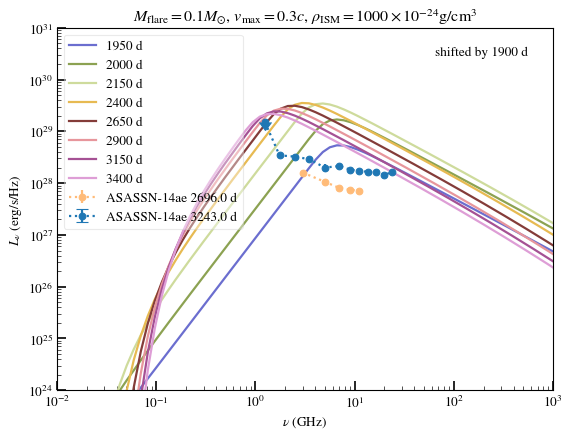

In [55]:
keys_list = list(dict_constism_toSED['ASASSN-14ae'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'ASASSN-14ae',epoch_delta=dict_constism_toSED['ASASSN-14ae'][keys_list[0]],range_to_incl=1000)
#may need flatter spectrum at 3200 d?

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 750 \times 10^{-24} \mathrm{g/cm^3}$ AT2018dyb 1522.8
3


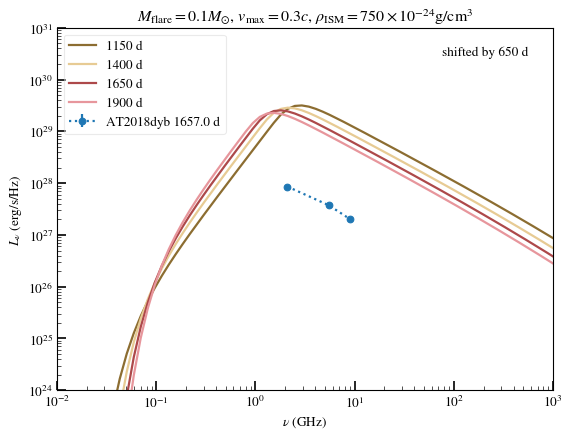

In [56]:
keys_list = list(dict_constism_toSED['AT2018dyb'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'AT2018dyb',epoch_delta=dict_constism_toSED['AT2018dyb'][keys_list[0]])#,range_to_incl=1000)

$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$ AT2018zr 1618.5454545454545
4


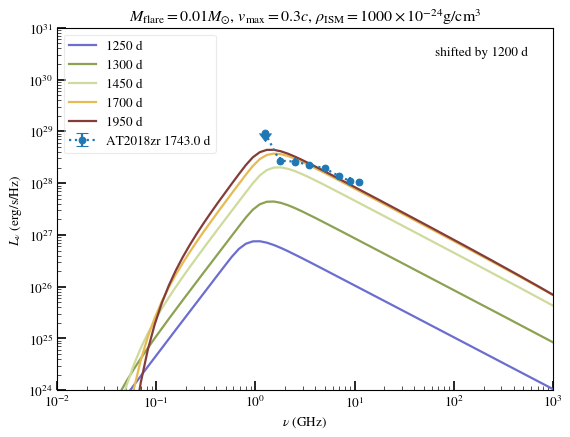

In [138]:
keys_list = list(dict_constism_toSED['AT2018zr'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'AT2018zr',epoch_delta=dict_constism_toSED['AT2018zr'][keys_list[0]])#,range_to_incl=1000)
#maybe this one needs flatter spectrum?

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 500 \times 10^{-24} \mathrm{g/cm^3}$ AT2019dsg 1099.0
4


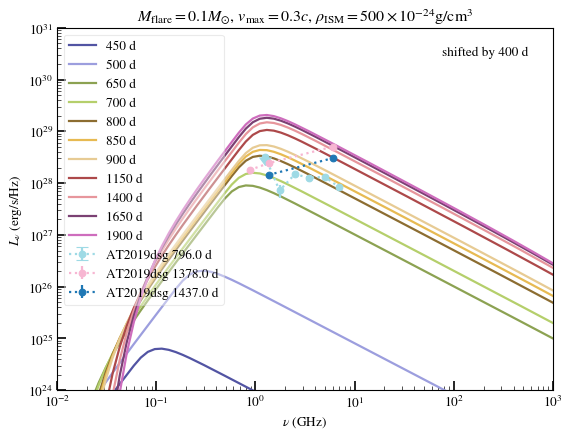

In [140]:
keys_list = list(dict_constism_toSED['AT2019dsg'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'AT2019dsg',epoch_delta=dict_constism_toSED['AT2019dsg'][keys_list[0]],range_to_incl=1000)


$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$ AT2019eve 1056.8285714285714
8


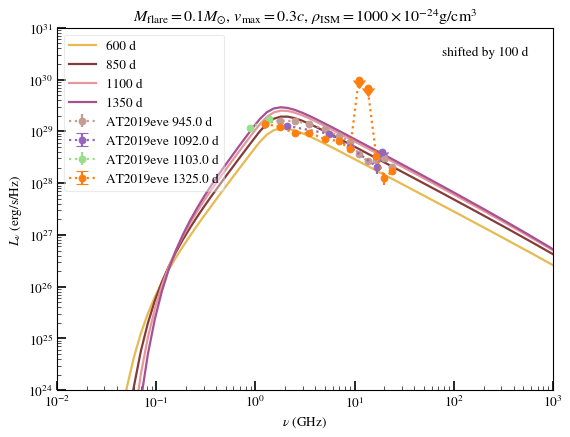

In [80]:
keys_list = list(dict_constism_toSED['AT2019eve'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'AT2019eve',epoch_delta=dict_constism_toSED['AT2019eve'][keys_list[0]])#,range_to_incl=1000)
#maybe this one needs flatter spectrum

$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm max} = 0.3c$, $\rho_{\rm ISM} = 1000 \times 10^{-24} \mathrm{g/cm^3}$ PS16dtm 1483.2272727272727
9


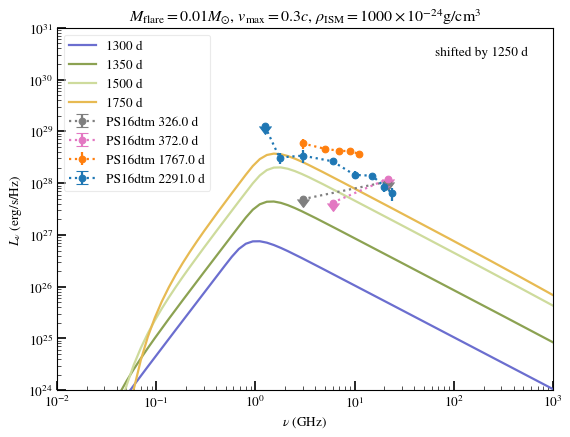

In [141]:
keys_list = list(dict_constism_toSED['PS16dtm'].keys())
plot_rhoISM_SED(model_name=keys_list[0],modeldict_name=dict_constism,event_name = 'PS16dtm',epoch_delta=dict_constism_toSED['PS16dtm'][keys_list[0]])#,range_to_incl=1000)
# plot_rhoISM_SED(model_name=keys_list[1],modeldict_name=dict_constism,event_name = 'PS16dtm',epoch_delta=dict_constism_toSED['PS16dtm'][keys_list[1]])#,range_to_incl=1000)
#something in between these two?

## Two flares colliding

In [83]:
def plot_twoflares_SED(model_name,modeldict_name,event_name,epoch_delta,range_to_incl=500):

    
    fig,ax = plt.subplots(figsize=(8, 6))

    # linestyles = ['-','--',':','-.','-']
    # for i, model_name in enumerate(sorted(os.listdir(model_dir))):
        # if i >=2:
        #     continue
    
    approx_time = np.average(dict_events[event_name]['times (d)'])
    print(model_name,event_name,approx_time)
    flare1_SEDs_dict = np.load(modeldict_name[model_name]+'/flare1/SED_data.npz',allow_pickle=True)['SED_vs_epoch'].item()
    flare2_SEDs_dict = np.load(modeldict_name[model_name]+'/flare2/SED_data.npz',allow_pickle=True)['SED_vs_epoch'].item()
    
    colors = plt.cm.tab20b(np.linspace(0, 1, len(flare1_SEDs_dict.keys())))
    for j, key in enumerate(flare1_SEDs_dict.keys()):

        if key=='nu_ph_vals_GHz':
            continue
        epoch = float(key.split('_')[-1])+epoch_delta
        
        if np.abs(epoch-approx_time) > range_to_incl:
            continue
        # if i==0:
        label_to_use='{:0.0f} d'.format(epoch)
        # else:
        #     label_to_use = None
        ax.plot(flare2_SEDs_dict['nu_ph_vals_GHz'],flare2_SEDs_dict[key]+flare1_SEDs_dict[key],label=label_to_use,linestyle='-',color=colors[j])

    colors2 = plt.cm.tab20_r(np.linspace(0, 1, len(np.unique(dict_events[event_name]['times (d)']))))
    print(len(np.unique(dict_events[event_name]['times (d)'])))
    for j,epoch in enumerate(np.unique(dict_events[event_name]['times (d)'])):

        epoch_array = np.array([],dtype=int)
        uplims_array = np.array([],dtype=bool)
        for i in range(len(dict_events[event_name]['times (d)'])):
            if dict_events[event_name]['times (d)'][i] == epoch:
                # print(i)
                epoch_array = np.append(epoch_array,i)
                if dict_events[event_name]['error (mJy)'][i] == 0:
                    uplims_array = np.append(uplims_array,True)
                else:
                    uplims_array = np.append(uplims_array,False)
        if len(epoch_array) == 1:
            continue
        ax.errorbar(dict_events[event_name]['freq (GHz)'][epoch_array], dict_events[event_name]['Lnu (erg/s/Hz)'][epoch_array], 
                    yerr=dict_events[event_name]['error (erg/s/Hz)'][epoch_array], fmt='o',  uplims=uplims_array,
                    ms=6, label=event_name+f' {epoch} d',color=colors2[j],linestyle=':')
                    # unique=False
    ax.text(0.95, 0.95, f'shifted by {epoch_delta:0.0f} d', transform=ax.transAxes, fontsize=12, verticalalignment='top',horizontalalignment='right')
    ax.set_xscale('log')
    ax.set_yscale('log')    
    ax.set_xlim(1e-2,1e3)
    ax.set_ylim(1e24,1e31)
    ax.set_xlabel(r'$\nu$ (GHz)')
    ax.set_ylabel(r'$L_\nu$ (erg/s/Hz)')
    plt.title(f'{model_name}')
    plt.legend(loc='upper left')
    return

In [48]:
dict_2flares_toSED

{'iPTF16fnl': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm min} = 0.03c$, $v_{\\rm max} = 0.3c$, $\\Delta t=0.3$yr': 1300.0},
 'AT2018dyb': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm min} = 0.03c$, $v_{\\rm max} = 0.3c$, $\\Delta t=1$yr': 1100.0},
 'AT2018zr': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm min} = 0.03c$, $v_{\\rm max} = 0.3c$, $\\Delta t=0.3$yr': 1500.0,
  '$M_{\\rm flare} = 0.01M_{\\odot}$, $v_{\\rm min} = 0.03c$, $v_{\\rm max} = 0.3c$, $\\Delta t=0.3$yr, $p=2.1$': 1560.0},
 'AT2019teq': {'$M_{\\rm flare} = 0.1M_{\\odot}$, $v_{\\rm min} = 0.03c$, $v_{\\rm max} = 0.3c$, $\\Delta t=0.3$yr': 925.0,
  '$M_{\\rm flare} = 0.01M_{\\odot}$, $v_{\\rm min} = 0.03c$, $v_{\\rm max} = 0.3c$, $\\Delta t=0.3$yr, $p=2.1$': 1000.0}}

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr iPTF16fnl 1687.5
2


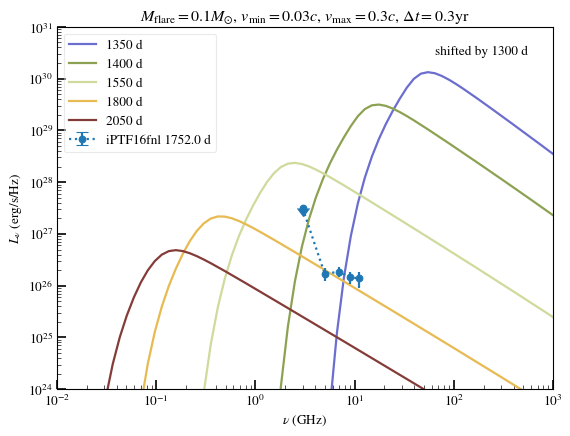

In [84]:
keys_list = list(dict_2flares_toSED['iPTF16fnl'].keys())
plot_twoflares_SED(model_name=keys_list[0],modeldict_name=dict_2flares,event_name = 'iPTF16fnl',epoch_delta=dict_2flares_toSED['iPTF16fnl'][keys_list[0]])

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=1$yr AT2018dyb 1522.8
3


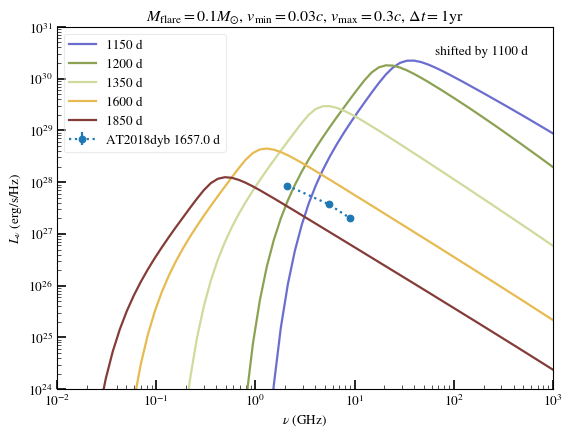

In [85]:
keys_list = list(dict_2flares_toSED['AT2018dyb'].keys())
plot_twoflares_SED(model_name=keys_list[0],modeldict_name=dict_2flares,event_name = 'AT2018dyb',epoch_delta=dict_2flares_toSED['AT2018dyb'][keys_list[0]])

$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr AT2018zr 1618.5454545454545
4
$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr, $p=2.1$ AT2018zr 1618.5454545454545
4


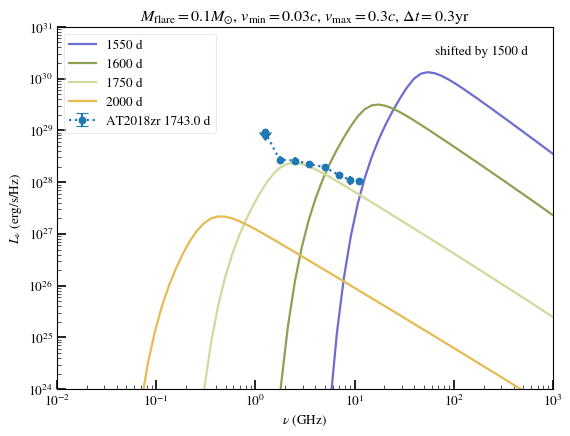

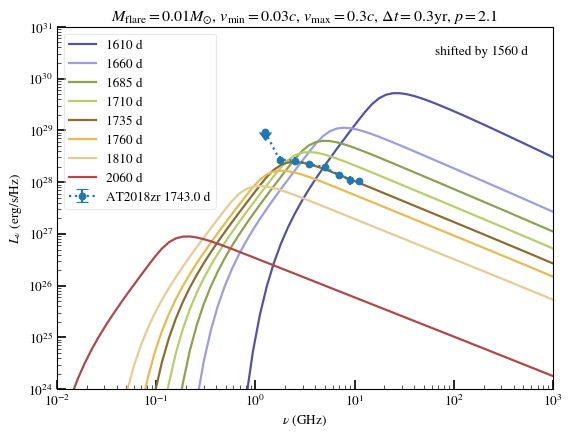

In [86]:
keys_list = list(dict_2flares_toSED['AT2018zr'].keys())
plot_twoflares_SED(model_name=keys_list[0],modeldict_name=dict_2flares,event_name = 'AT2018zr',epoch_delta=dict_2flares_toSED['AT2018zr'][keys_list[0]])

plot_twoflares_SED(model_name=keys_list[1],modeldict_name=dict_2flares,event_name = 'AT2018zr',epoch_delta=dict_2flares_toSED['AT2018zr'][keys_list[1]])


$M_{\rm flare} = 0.1M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr AT2019teq 1068.7
3
$M_{\rm flare} = 0.01M_{\odot}$, $v_{\rm min} = 0.03c$, $v_{\rm max} = 0.3c$, $\Delta t=0.3$yr, $p=2.1$ AT2019teq 1068.7
3


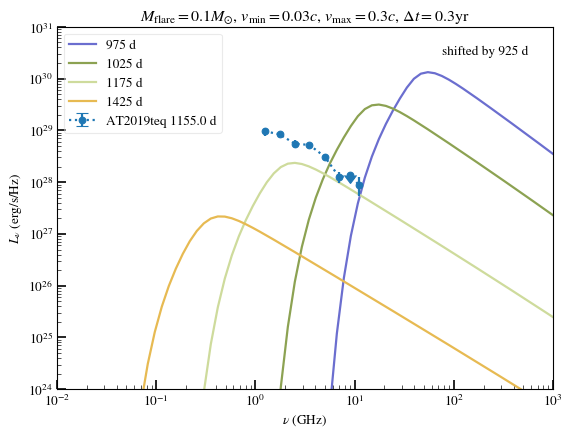

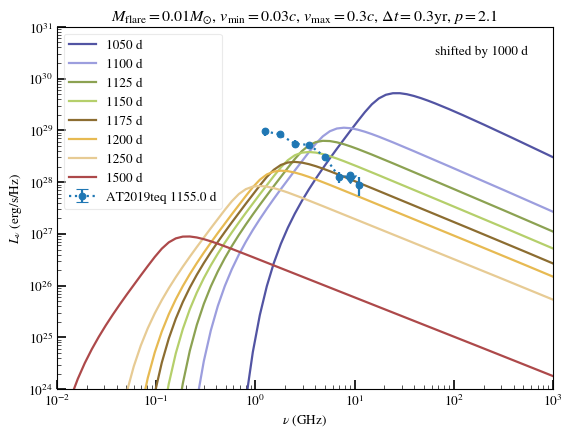

In [87]:
keys_list = list(dict_2flares_toSED['AT2019teq'].keys())
plot_twoflares_SED(model_name=keys_list[0],modeldict_name=dict_2flares,event_name = 'AT2019teq',epoch_delta=dict_2flares_toSED['AT2019teq'][keys_list[0]])

plot_twoflares_SED(model_name=keys_list[1],modeldict_name=dict_2flares,event_name = 'AT2019teq',epoch_delta=dict_2flares_toSED['AT2019teq'][keys_list[1]])